In [114]:
import numpy as np
import cv2 #to work with images
from skimage.measure import label, regionprops_table #to get shape properties
import pandas as pd #make spreadsheet
from scipy import ndimage as ndi #for watershed segmentation
from skimage.feature import peak_local_max #for watershed segmentation
from skimage.segmentation import watershed #for watershed segmentation
import os
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from skimage.morphology import dilation, disk

In [115]:
def get_labels(img):
    distance = ndi.distance_transform_edt(img)
    local_max_coords = peak_local_max(distance, min_distance=50)
    local_max_mask = np.zeros(distance.shape, dtype=bool)
    local_max_mask[tuple(local_max_coords.T)] = True
    markers = label(local_max_mask)
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [116]:
def new_method(img):
    distance = ndi.distance_transform_edt(img)
    sure_fg_mask = distance > 0.1 * distance.max()
    markers = label(sure_fg_mask)
    sure_bg_mask = dilation(img, disk(5))
    markers[sure_bg_mask == 0] = markers.max() + 1
    segmented_cells = watershed(-distance, markers, mask=img)
    return segmented_cells

In [117]:
def get_axon_row(axon_df, left, right, top, bottom):
    '''
    Using the myelin bounding box find the larges axon that correspons to that myelin
    '''
    
    left = int(left)
    right = int(right)
    top = int(top)
    bottom = int(bottom)
    
    axons_id = axon_df[(((axon_df['centroid-0'])>=left) & (axon_df['centroid-0']<=right)) &
                       ((axon_df['centroid-1'])>=top) & (axon_df['centroid-1']<=bottom)]
    biggest_axon = axons_id[axons_id['area'] == axons_id['area'].max()]
    
    return biggest_axon


In [118]:
def get_morphometrics(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = get_labels(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = get_labels(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
                new_dict = {'label':label,
                        'x':x,
                        'y':y,
                        'axon_area':axon_area,
                        'axon_perimeter':axon_perimeter,
                        'axon_diam':axon_diam,
                        'myelin_area':myelin_area,
                        'myelin_thickness':myelin_thickness,
                        'myelin_perimeter':myelin_perimeter,
                        'eccentricity':eccentricity,
                        'orientation':orientation,
                        'solidity':solidity,
                        'gratio':gratio}

                new_df = pd.DataFrame(new_dict)
                
                #add the new data to the morphometrics DataFrame
                morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [119]:
def get_morphometrics_new(img_path):
    '''
    Get morphometric data from a single image and return a pandas df of the morphometric data
    
    :param img_path: A path (string or object) pointing to a single segmented image in which the myelin is a middle grey and the axon is white
    
    :returns: Pandas DataFrame; morphometrics
    '''
    
    #read the image and flatten it into black and white
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axon = cv2.inRange(img, 200, 255) #axons are everything above a medium gray
    myelin = cv2.inRange(img, 1, 255) #myelin is actually axon+myelin so everything above black
    
    #watershed labelling of axons then obtaining region properties and putting it in a DataFrame
    axon_label = new_method(axon)
    axon_props = regionprops_table(axon_label,properties=('label', 'centroid', 'area', 'axis_minor_length', 'axis_major_length', 
                                                          'eccentricity', 'orientation', 'perimeter', 'solidity'))
    axon_df = pd.DataFrame.from_dict(axon_props)

    #watershed labelling of myelin then obtaining region properties and putting it in a DataFrame
    myelin_label = new_method(myelin)
    myelin_props = regionprops_table(myelin_label, properties=('label', 'bbox', 'area', 'axis_minor_length', 'axis_major_length',
                                                               'perimeter'))
    myelin_df = pd.DataFrame.from_dict(myelin_props)
    
    #making an empty DataFrame to put morphometric data into
    columns = {'label':[],
               'x':[],
               'y':[],
               'axon_area':[],
               'axon_perimeter':[],
               'axon_diam':[],
               'myelin_area':[],
               'myelin_thickness':[],
               'myelin_perimeter':[],
               'eccentricity':[],
               'orientation':[],
               'solidity':[],
               'gratio':[]}
    morph_df1 = pd.DataFrame(columns)
    morph_df2 = pd.DataFrame(columns)
    
    #going through all the myelin that got accounted for in watershed
    #using myelin to compare to axons
    drop_rows = []    
    for index, row in myelin_df.iterrows():
        left = row['bbox-0']
        right = row['bbox-2']
        top = row['bbox-1']
        bottom = row['bbox-3']
        
        axon_row = get_axon_row(axon_df, left, right, top, bottom)
        if not(axon_row.empty):
            label = row['label']
            x = axon_row['centroid-0']
            y = axon_row['centroid-1']
            axon_area = axon_row['area']
            axon_perimeter = axon_row['perimeter']
            axon_diam = axon_row['axis_major_length']#(row['axis_major_length'] + row['axis_minor_length']) / 2 #getting axon diameter along the major axis
            eccentricity = axon_row['eccentricity']
            orientation = axon_row['orientation']
            solidity = axon_row['solidity']
            
            myelin_area = row['area'] - axon_area
            myelin_thickness = row['axis_major_length']
            myelin_perimeter = row['perimeter']
            gratio = axon_diam / row['axis_major_length']
            
            if gratio.iloc[0] < 1:
                #make a one row DataFrame with axon and myelin data
                new_dict = {'label':label,
                        'x':x,
                        'y':y,
                        'axon_area':axon_area,
                        'axon_perimeter':axon_perimeter,
                        'axon_diam':axon_diam,
                        'myelin_area':myelin_area,
                        'myelin_thickness':myelin_thickness,
                        'myelin_perimeter':myelin_perimeter,
                        'eccentricity':eccentricity,
                        'orientation':orientation,
                        'solidity':solidity,
                        'gratio':gratio}

                new_df = pd.DataFrame(new_dict)
                
                #add the new data to the morphometrics DataFrame
                morph_df2 = pd.concat([morph_df2,new_df], ignore_index=True)
        
    morph_df2 = morph_df2.drop(drop_rows)
    return axon_label, myelin_label, morph_df2

In [ ]:
test_img = r"C:\Users\kushs\deepaxon\P1503_CUNProx_40X_009.tif"
img = cv2.imread(test_img, 0)

In [121]:
axons, myelin, df = get_morphometrics(test_img)
df

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,1.0,51.552805,2306.716441,2585.0,214.409163,80.362524,5460.0,126.624777,364.747258,0.844978,-1.254285,0.916342,0.634651
1,2.0,44.460930,645.843719,1011.0,181.681241,63.463432,2852.0,95.966055,501.108694,0.888722,1.045926,0.658632,0.661311
2,3.0,67.580048,1521.463136,6646.0,319.622366,94.408791,6926.0,136.932918,453.989899,0.228237,0.902136,0.956259,0.689453
3,4.0,70.342679,933.256490,963.0,125.982756,43.414142,1497.0,68.203269,198.409163,0.718205,-1.105100,0.950642,0.636540
4,5.0,80.717378,485.795550,1663.0,200.308658,64.169510,3668.0,91.408206,440.031529,0.792416,0.243493,0.738783,0.702010
...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,287.0,1957.144543,380.156342,678.0,113.396970,43.110782,2560.0,85.232582,246.894444,0.836334,-1.339688,0.848561,0.505802
278,288.0,1962.644578,584.319277,830.0,139.296465,55.699269,3176.0,92.879074,306.634560,0.925565,-0.205036,0.814524,0.599697
279,289.0,1980.947462,278.453486,5063.0,281.320851,102.199792,6295.0,145.858013,414.717821,0.782378,1.225861,0.976471,0.700680
280,290.0,1969.821429,1295.650621,644.0,148.669048,72.732391,4019.0,116.363992,296.735065,0.981253,0.021648,0.736000,0.625042


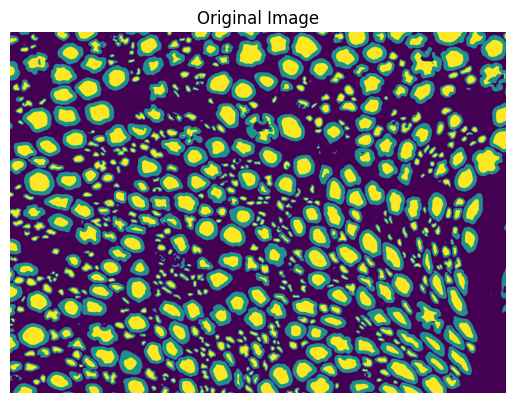

In [122]:
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

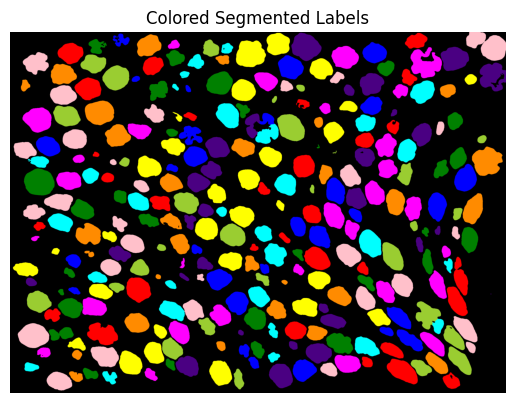

In [123]:
# Convert labels to RGB image with unique colors
colored_labels_original = label2rgb(myelin, bg_label=0)

# Display
plt.imshow(colored_labels_original)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

In [124]:
axons, myelin, df = get_morphometrics_new(test_img)
df

,label,x,y,axon_area,axon_perimeter,axon_diam,myelin_area,myelin_thickness,myelin_perimeter,eccentricity,orientation,solidity,gratio
0,2.0,16.037353,295.589777,1526.0,155.195959,59.034872,1636.0,84.955162,227.338095,0.825680,1.272398,0.969504,0.694894
1,3.0,15.497944,428.394019,2675.0,234.710678,92.128780,2593.0,130.143583,323.338095,0.899267,-1.462182,0.981291,0.707901
2,6.0,6.242152,905.372197,223.0,55.798990,18.863329,225.0,28.662629,80.627417,0.566507,-1.150313,0.957082,0.658116
3,7.0,12.630610,1082.158803,1738.0,179.876154,73.230446,2318.0,109.032104,274.610173,0.901633,-1.514921,0.974762,0.671641
4,8.0,12.634591,1193.555346,1590.0,180.225397,69.608330,2294.0,108.372632,276.509668,0.884648,-1.380107,0.945866,0.642305
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,666.0,2035.148459,1150.781513,357.0,70.627417,25.947003,471.0,34.927899,107.455844,0.730293,0.059879,0.964865,0.742873
510,667.0,2035.452830,1626.766038,265.0,70.526912,27.012805,405.0,35.469751,105.840620,0.845319,-0.186801,0.835962,0.761573
511,668.0,2040.297561,1211.892683,205.0,54.142136,19.211193,373.0,33.311239,93.597980,0.664964,-0.606770,0.976190,0.576718
512,669.0,2034.827715,1089.176030,267.0,92.597980,36.486186,479.0,46.601417,123.497475,0.916189,0.129509,0.635714,0.782942


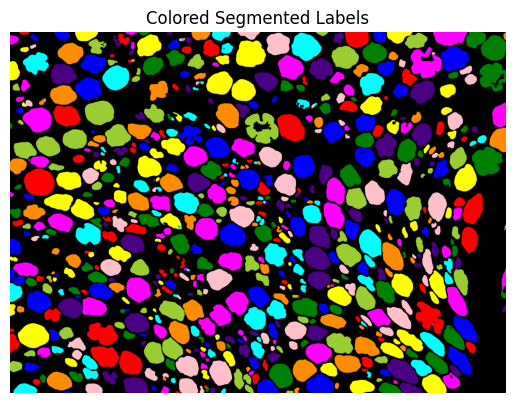

In [125]:
# Convert labels to RGB image with unique colors
colored_labels = label2rgb(myelin, bg_label=0)

# Display
plt.imshow(colored_labels)
plt.title("Colored Segmented Labels")
plt.axis('off')
plt.show()

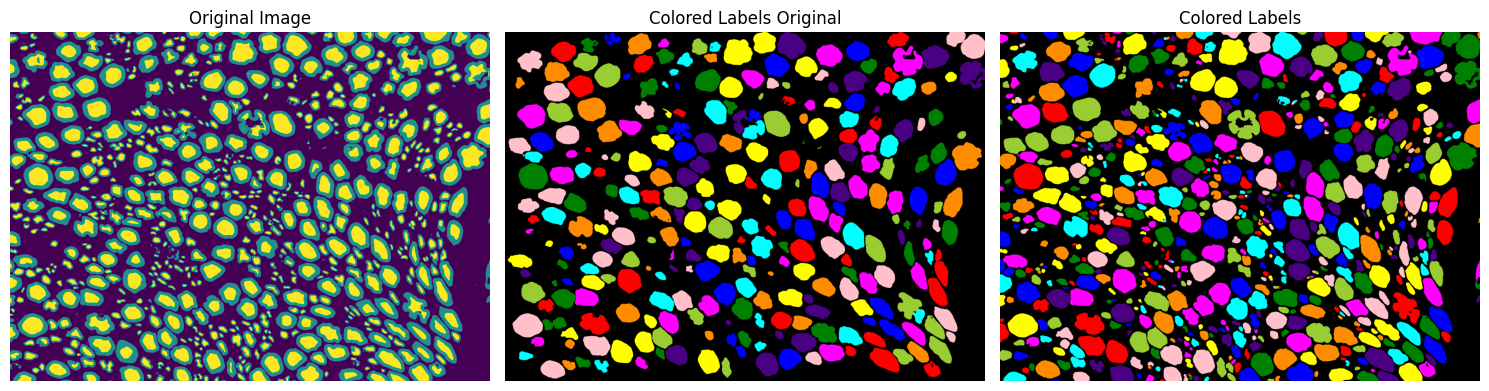

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off') # Hide the axes ticks

axes[1].imshow(colored_labels_original)
axes[1].set_title('Original Watershed')
axes[1].axis('off')

axes[2].imshow(colored_labels)
axes[2].set_title('New Watershed')
axes[2].axis('off')

plt.tight_layout()

plt.show()